In [32]:
import warnings
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Data Acquisition

In [19]:
os.chdir('d:/Repository/homecredit_credit_scoring_model/dataset')
warnings.filterwarnings('ignore')


In [20]:
train = pd.read_csv('application_train.csv')

# Exploratory Data Analysis (EDA) & Cleaning

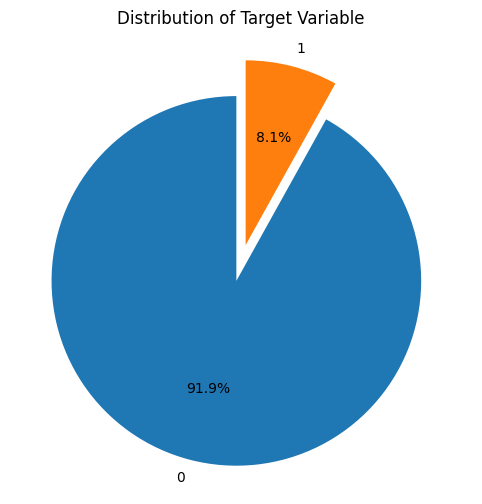

In [21]:
train.TARGET.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Distribution of Target Variable',
    legend=False,
    figsize=(8, 6),
    color=['#007bff', '#dc3545'],
    startangle=90,
    explode=(0.1, 0.1)
)
plt.show()

# Modelling

## Splitting

In [22]:
X = train.drop(columns=['TARGET'])
y = train['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


## Pipelining

In [23]:
numerical_features = X_train.select_dtypes(include=['number']).columns
categorical_features = X_train.select_dtypes(exclude=['number']).columns

In [24]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='error', drop='first')),
])

preprocessor = ColumnTransformer([
    ('numerical', numerical_transformer, numerical_features),
    ('categorical', categorical_transformer, categorical_features),
], remainder='passthrough')

In [25]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('logistic', LogisticRegression(random_state=42)),
])

# Evaluation & Tuning:

## Logistic Regression

In [33]:
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56530
           1       0.16      0.66      0.26      4973

    accuracy                           0.70     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.70      0.76     61503



In [ ]:
## Decision Tree